# Отказоустойчивый инференс компьютерного зрения

Использован датасет KolektorSDD2 https://www.vicos.si/resources/kolektorsdd2/

## План работы

1. Загрузить и проверить датасет.
2. Посмотреть дисбаланс классов.
3. Подготовить предобработку и аугментации для дефектного класса.
4. Провести быстрый эксперимент до и после балансировки.
5. Оценить финальные модели `ResNet50` и `MobileNetV2`.
6. Посмотреть monitoring-сигналы.
7. Проверить fallback-инференс и замерить задержку.

Почему это важно:
- при сильном дисбалансе модель может хорошо угадывать класс `normal`, но пропускать дефекты;
- балансировка выборки, oversampling и аугментации повышают шанс увидеть больше сложных дефектных примеров;
- fallback-модель нужна на случай сбоя, таймаута или низкой уверенности основной модели.

In [ ]:
import time
import os
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import MobileNet_V2_Weights, ResNet50_Weights, mobilenet_v2, resnet50

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'app').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from app.model_inference.fallback_service import predict_with_fallback as backend_predict_with_fallback
from app.model_inference.monitoring import (
    compute_blur_score,
    compute_brightness,
    compute_confidence,
    compute_entropy,
)

DATA_DIR = PROJECT_ROOT / 'data' / 'KolektorSDD2'
MODELS_DIR = PROJECT_ROOT / 'models'
RESNET_MODEL_PATH = MODELS_DIR / 'resnet50_main.pth'
MOBILENET_MODEL_PATH = MODELS_DIR / 'mobilenetv2_fallback.pth'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
IMAGE_SIZE = (224, 224)
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
RANDOM_STATE = 42
VALIDATION_SIZE = 0.2
TARGET_POSITIVE_RATIO = 0.5
MAIN_DROPOUT = 0.35
FALLBACK_DROPOUT = 0.25
CONFIDENCE_THRESHOLD = 0.75
TIMEOUT_THRESHOLD = 1.0
LABEL_TO_NAME = {0: 'normal', 1: 'defect'}

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)


def mask_to_label(mask_path: Path) -> int:
    mask = np.array(Image.open(mask_path).convert('L'))
    return int((mask > 0).any())


def build_metadata_dataframe(data_dir: Path = DATA_DIR) -> pd.DataFrame:
    if not data_dir.exists():
        raise FileNotFoundError(f'Dataset directory was not found: {data_dir}')

    rows = []
    for split_name in ('train', 'test'):
        split_dir = data_dir / split_name
        for image_path in sorted(split_dir.glob('*.png')):
            if image_path.name.endswith('_GT.png'):
                continue
            mask_path = image_path.with_name(f'{image_path.stem}_GT.png')
            if not mask_path.exists():
                continue
            rows.append({
                'image_id': image_path.stem,
                'image_path': str(image_path.relative_to(PROJECT_ROOT)),
                'mask_path': str(mask_path.relative_to(PROJECT_ROOT)),
                'split': split_name,
                'label': mask_to_label(mask_path),
            })
    return pd.DataFrame(rows)


def split_dataframe(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    return (
        df[df['split'] == 'train'].reset_index(drop=True),
        df[df['split'] == 'test'].reset_index(drop=True),
    )


def describe_class_balance(df: pd.DataFrame) -> pd.DataFrame:
    balance_df = (
        df.groupby(['split', 'label'])
        .size()
        .reset_index(name='count')
        .sort_values(['split', 'label'])
        .reset_index(drop=True)
    )
    split_totals = balance_df.groupby('split')['count'].transform('sum')
    balance_df['ratio'] = balance_df['count'] / split_totals
    balance_df['label_name'] = balance_df['label'].map({0: 'normal', 1: 'defect'})
    return balance_df


class AddGaussianNoise:
    def __init__(self, std: float = 0.03) -> None:
        self.std = std

    def __call__(self, tensor: torch.Tensor) -> torch.Tensor:
        noise = torch.randn_like(tensor) * self.std
        return torch.clamp(tensor + noise, 0.0, 1.0)


def get_image_transform(image_size: tuple[int, int] = IMAGE_SIZE):
    return transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize(image_size),
        transforms.ToTensor(),
    ])


def get_positive_augment_transform(image_size: tuple[int, int] = IMAGE_SIZE):
    return transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize(image_size),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.3),
        transforms.RandomAffine(degrees=12, translate=(0.05, 0.05), scale=(0.92, 1.08)),
        transforms.RandomPerspective(distortion_scale=0.15, p=0.3),
        transforms.RandomApply([transforms.ColorJitter(brightness=0.25, contrast=0.25)], p=0.5),
        transforms.RandomApply([transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 1.2))], p=0.3),
        transforms.RandomAdjustSharpness(sharpness_factor=1.5, p=0.3),
        transforms.ToTensor(),
        transforms.RandomApply([AddGaussianNoise(std=0.03)], p=0.35),
    ])


def balance_dataframe_to_ratio(
    dataframe: pd.DataFrame,
    target_positive_ratio: float = TARGET_POSITIVE_RATIO,
    random_state: int = RANDOM_STATE,
) -> pd.DataFrame:
    if dataframe.empty or dataframe['label'].nunique() < 2:
        return dataframe.reset_index(drop=True)

    positive_df = dataframe[dataframe['label'] == 1]
    negative_df = dataframe[dataframe['label'] == 0]
    if positive_df.empty or negative_df.empty:
        return dataframe.reset_index(drop=True)

    negative_count = len(negative_df)
    desired_positive_count = int(round(negative_count * target_positive_ratio / max(1e-8, 1 - target_positive_ratio)))
    desired_positive_count = max(len(positive_df), desired_positive_count)
    additional_count = desired_positive_count - len(positive_df)

    base_positive_df = positive_df.copy()
    base_positive_df['is_augmented'] = False
    negative_df = negative_df.copy()
    negative_df['is_augmented'] = False

    if additional_count <= 0:
        balanced_df = pd.concat([negative_df, base_positive_df], axis=0)
        return balanced_df.sample(frac=1.0, random_state=random_state).reset_index(drop=True)

    sampled_positive_df = positive_df.sample(n=additional_count, replace=True, random_state=random_state).copy()
    sampled_positive_df['is_augmented'] = True
    balanced_df = pd.concat([negative_df, base_positive_df, sampled_positive_df], axis=0)
    return balanced_df.sample(frac=1.0, random_state=random_state).reset_index(drop=True)


class KolektorDataset(Dataset):
    def __init__(self, dataframe, transform=None, positive_transform=None, augment_positive=False):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform or get_image_transform()
        self.positive_transform = positive_transform or get_positive_augment_transform()
        self.augment_positive = augment_positive

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        label = int(row['label'])
        image = Image.open(PROJECT_ROOT / row['image_path']).convert('L')
        is_augmented = bool(row.get('is_augmented', False))
        if self.augment_positive and label == 1 and is_augmented:
            image_tensor = self.positive_transform(image)
        else:
            image_tensor = self.transform(image)
        return image_tensor, label


def initialize_resnet50(num_classes: int = 2, dropout: float = MAIN_DROPOUT):
    model = resnet50(weights=ResNet50_Weights.DEFAULT)
    model.fc = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(model.fc.in_features, num_classes),
    )
    return model


def initialize_mobilenet_v2(num_classes: int = 2, dropout: float = FALLBACK_DROPOUT):
    model = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(in_features, num_classes),
    )
    return model


def classification_report_dict(y_true, y_pred) -> dict:
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
        'precision_normal': float(precision_score(y_true, y_pred, pos_label=0, zero_division=0)),
        'recall_normal': float(recall_score(y_true, y_pred, pos_label=0, zero_division=0)),
        'f1_normal': float(f1_score(y_true, y_pred, pos_label=0, zero_division=0)),
        'precision_defect': float(precision_score(y_true, y_pred, pos_label=1, zero_division=0)),
        'recall_defect': float(recall_score(y_true, y_pred, pos_label=1, zero_division=0)),
        'f1_defect': float(f1_score(y_true, y_pred, pos_label=1, zero_division=0)),
        'confusion_matrix': confusion_matrix(y_true, y_pred).tolist(),
    }


def compute_recall_accuracy_score(metrics: dict) -> float:
    return float(np.sqrt(metrics['accuracy'] * metrics['recall_defect']))


def train_one_epoch(model, dataloader, criterion, optimizer, device=DEVICE) -> dict:
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return {
        'loss': running_loss / max(total, 1),
        'accuracy': correct / max(total, 1),
    }


@torch.no_grad()
def evaluate_model(model, dataloader, criterion, device=DEVICE) -> dict:
    model.eval()
    running_loss = 0.0
    total = 0
    all_labels = []
    all_predictions = []
    all_probabilities = []

    for images, labels in dataloader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = model(images)
        loss = criterion(logits, labels)
        probabilities = torch.softmax(logits, dim=1)
        predictions = logits.argmax(dim=1)

        running_loss += loss.item() * labels.size(0)
        total += labels.size(0)
        all_labels.extend(labels.cpu().tolist())
        all_predictions.extend(predictions.cpu().tolist())
        all_probabilities.extend(probabilities[:, 1].cpu().tolist())

    metrics = classification_report_dict(all_labels, all_predictions)
    metrics['loss'] = running_loss / max(total, 1)
    metrics['mean_defect_probability'] = float(np.mean(all_probabilities)) if all_probabilities else 0.0
    metrics['selection_score'] = compute_recall_accuracy_score(metrics)
    return metrics


def fit_classifier(
    model,
    train_loader,
    val_loader,
    train_labels,
    optimizer,
    scheduler,
    num_epochs,
    device=DEVICE,
    early_stopping_patience=3,
):
    criterion = nn.CrossEntropyLoss()
    best_state_dict = None
    best_val_metrics = None
    best_selection_score = -1.0
    epochs_without_improvement = 0
    history = []
    model = model.to(device)

    for epoch in range(num_epochs):
        train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device=device)
        val_metrics = evaluate_model(model, val_loader, criterion, device=device)

        if scheduler is not None:
            scheduler.step(val_metrics['loss'])

        current_lr = optimizer.param_groups[0]['lr']
        history.append({
            'epoch': epoch + 1,
            'train_loss': train_metrics['loss'],
            'train_accuracy': train_metrics['accuracy'],
            'val_loss': val_metrics['loss'],
            'val_accuracy': val_metrics['accuracy'],
            'val_recall_defect': val_metrics['recall_defect'],
            'val_precision_defect': val_metrics['precision_defect'],
            'val_f1_defect': val_metrics['f1_defect'],
            'learning_rate': current_lr,
        })

        if val_metrics['selection_score'] > best_selection_score:
            best_selection_score = val_metrics['selection_score']
            best_val_metrics = val_metrics
            best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= early_stopping_patience:
            break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return model, history, 0.5, (best_val_metrics or {})


def darken_image(image: np.ndarray, factor: float = 0.5) -> np.ndarray:
    return np.clip(np.asarray(image, dtype=np.float32) * factor, 0, 255).astype(np.uint8)


def blur_image(image: np.ndarray, kernel_size: tuple[int, int] = (5, 5)) -> np.ndarray:
    return cv2.GaussianBlur(np.asarray(image, dtype=np.uint8), kernel_size, sigmaX=0)


def add_gaussian_noise(image: np.ndarray, std: float = 10.0) -> np.ndarray:
    noise = np.random.normal(loc=0.0, scale=std, size=np.asarray(image).shape)
    return np.clip(np.asarray(image, dtype=np.float32) + noise, 0, 255).astype(np.uint8)


def collect_monitoring_signals(image: np.ndarray, probabilities=None) -> dict:
    signals = {
        'brightness': compute_brightness(image),
        'blur_score': compute_blur_score(image),
    }
    if probabilities is not None:
        signals['confidence'] = compute_confidence(probabilities)
        signals['entropy'] = compute_entropy(probabilities)
    return signals


def load_image_tensor(image_path: str | Path) -> torch.Tensor:
    image = Image.open(PROJECT_ROOT / image_path).convert('L')
    tensor = get_image_transform(image_size=IMAGE_SIZE)(image)
    return tensor.unsqueeze(0)


def predict_with_fallback(
    image_path,
    resnet_model,
    fallback_model,
    device=DEVICE,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    timeout_seconds=None,
    simulated_delay_seconds=0.0,
    force_main_failure=False,
):
    timeout_threshold = timeout_seconds if timeout_seconds is not None else TIMEOUT_THRESHOLD
    return backend_predict_with_fallback(
        image_path=image_path,
        main_model=resnet_model,
        fallback_model=fallback_model,
        device=device,
        confidence_threshold=confidence_threshold,
        timeout_threshold=timeout_threshold,
        simulated_delay_seconds=simulated_delay_seconds,
        force_main_failure=force_main_failure,
    )


print(f'Устройство: {DEVICE}')

Устройство: cuda


## 1. Загрузка данных

In [2]:
metadata_df = build_metadata_dataframe(DATA_DIR)
train_df, test_df = split_dataframe(metadata_df)

print(f"Всего изображений: {len(metadata_df)}")
print(f"Train: {len(train_df)}")
print(f"Test: {len(test_df)}")

metadata_df.head()

Всего изображений: 3335
Train: 2331
Test: 1004


,image_id,image_path,mask_path,split,label
0,10000,data\KolektorSDD2\train\10000.png,data\KolektorSDD2\train\10000_GT.png,train,0
1,10001,data\KolektorSDD2\train\10001.png,data\KolektorSDD2\train\10001_GT.png,train,0
2,10002,data\KolektorSDD2\train\10002.png,data\KolektorSDD2\train\10002_GT.png,train,0
3,10003,data\KolektorSDD2\train\10003.png,data\KolektorSDD2\train\10003_GT.png,train,0
4,10004,data\KolektorSDD2\train\10004.png,data\KolektorSDD2\train\10004_GT.png,train,0


## 2. Дисбаланс классов

In [3]:
balance_df = describe_class_balance(metadata_df)
balance_df

,split,label,count,ratio,label_name
0,test,0,894,0.890438,normal
1,test,1,110,0.109562,defect
2,train,0,2085,0.894466,normal
3,train,1,246,0.105534,defect


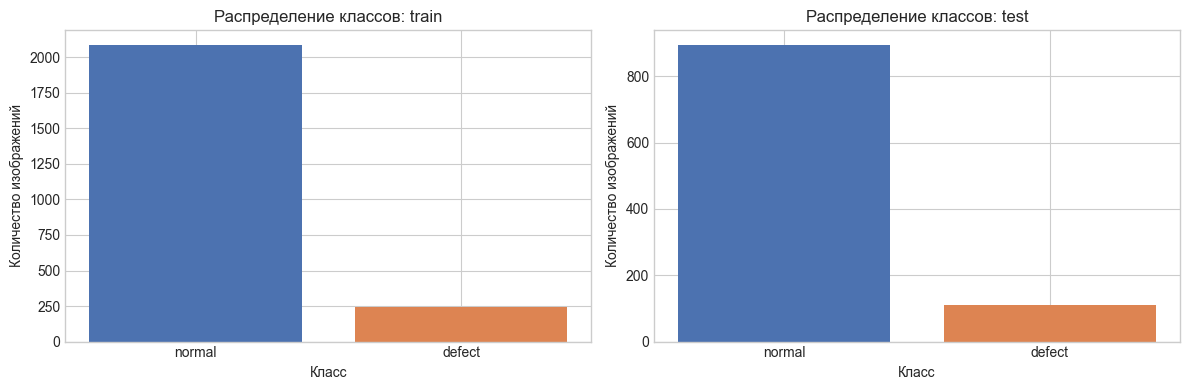

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for axis, split_name in zip(axes, ["train", "test"]):
    split_balance = balance_df[balance_df["split"] == split_name]
    axis.bar(split_balance["label_name"], split_balance["count"], color=["#4C72B0", "#DD8452"])
    axis.set_title(f"Распределение классов: {split_name}")
    axis.set_xlabel("Класс")
    axis.set_ylabel("Количество изображений")

plt.tight_layout()
plt.show()

## 3. Предобработка и аугментации

Для класса `defect` используется более сильная обработка:
- горизонтальные и вертикальные отражения;
- небольшие геометрические преобразования;
- изменение яркости и контраста;
- размытие;
- повышение резкости;
- добавление лёгкого шума.

Идея в том, чтобы расширить разнообразие дефектных примеров и приблизить баланс обучающей выборки к `50/50`.

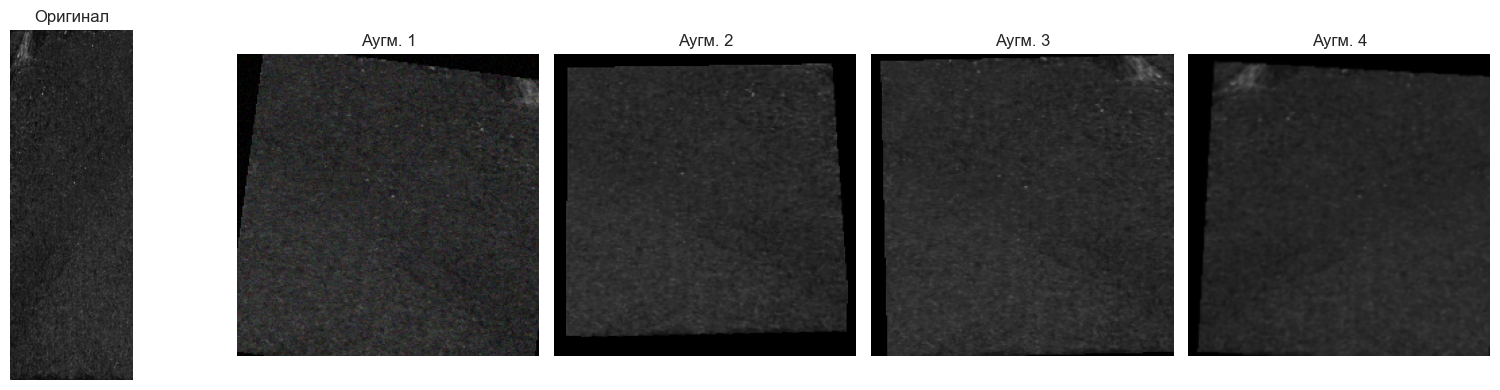

In [5]:
defect_row = metadata_df[metadata_df["label"] == 1].iloc[0]
defect_image = Image.open(defect_row["image_path"]).convert("L")
positive_transform = get_positive_augment_transform()

augmented_examples = [positive_transform(defect_image).permute(1, 2, 0).numpy() for _ in range(4)]

fig, axes = plt.subplots(1, 5, figsize=(16, 4))
axes[0].imshow(defect_image, cmap="gray")
axes[0].set_title("Оригинал")
axes[0].axis("off")

for index, image_array in enumerate(augmented_examples, start=1):
    axes[index].imshow(np.clip(image_array, 0.0, 1.0))
    axes[index].set_title(f"Аугм. {index}")
    axes[index].axis("off")

plt.tight_layout()
plt.show()

In [6]:
train_before_balance = train_df.copy().reset_index(drop=True)
train_before_balance["is_augmented"] = False
train_after_balance = balance_dataframe_to_ratio(train_before_balance, target_positive_ratio=TARGET_POSITIVE_RATIO)

balance_before_after = pd.DataFrame(
    [
        {
            "сценарий": "до аугментаций",
            "normal": int((train_before_balance["label"] == 0).sum()),
            "defect": int((train_before_balance["label"] == 1).sum()),
        },
        {
            "сценарий": "после балансировки",
            "normal": int((train_after_balance["label"] == 0).sum()),
            "defect": int((train_after_balance["label"] == 1).sum()),
        },
    ]
)
balance_before_after["доля_defect"] = (
    balance_before_after["defect"] / (balance_before_after["normal"] + balance_before_after["defect"])
).round(3)
balance_before_after

,сценарий,normal,defect,доля_defect
0,до аугментаций,2085,246,0.106
1,после балансировки,2085,2085,0.500


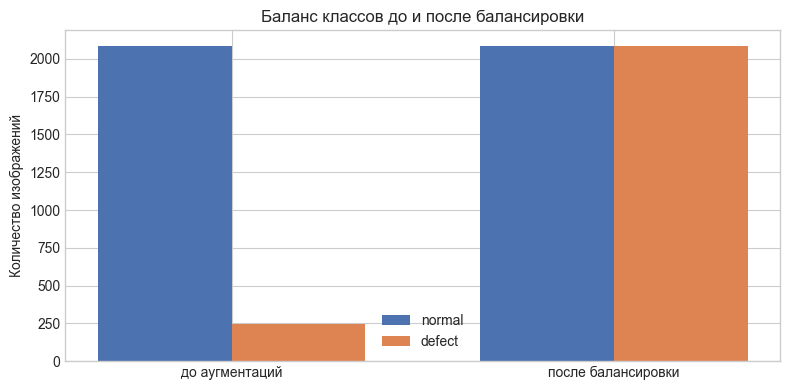

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(balance_before_after))
width = 0.35

ax.bar(x - width / 2, balance_before_after["normal"], width=width, label="normal", color="#4C72B0")
ax.bar(x + width / 2, balance_before_after["defect"], width=width, label="defect", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(balance_before_after["сценарий"])
ax.set_ylabel("Количество изображений")
ax.set_title("Баланс классов до и после балансировки")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Быстрый эксперимент: метрики до и после аугментаций

In [ ]:
def prepare_frames(use_balancing: bool):
    train_part_df, val_df = train_test_split(
        train_df,
        test_size=VALIDATION_SIZE,
        random_state=RANDOM_STATE,
        stratify=train_df['label'],
    )
    train_part_df = train_part_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)
    train_part_df['is_augmented'] = False
    val_df['is_augmented'] = False
    test_local_df = test_df.copy().reset_index(drop=True)
    test_local_df['is_augmented'] = False

    if use_balancing:
        train_part_df = balance_dataframe_to_ratio(
            train_part_df,
            target_positive_ratio=TARGET_POSITIVE_RATIO,
        )

    return train_part_df, val_df, test_local_df


def make_loaders(use_balancing: bool, use_positive_augmentation: bool, batch_size: int = 16):
    train_part_df, val_df, test_local_df = prepare_frames(use_balancing=use_balancing)
    base_transform = get_image_transform()
    positive_transform = get_positive_augment_transform()

    train_dataset = KolektorDataset(
        train_part_df,
        transform=base_transform,
        positive_transform=positive_transform,
        augment_positive=use_positive_augmentation,
    )
    val_dataset = KolektorDataset(val_df, transform=base_transform)
    test_dataset = KolektorDataset(test_local_df, transform=base_transform)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    return train_loader, val_loader, test_loader, train_part_df, val_df, test_local_df


def run_experiment(model_name: str, use_balancing: bool, use_positive_augmentation: bool, num_epochs: int = 6):
    train_loader, val_loader, test_loader, train_part_df, val_df, test_local_df = make_loaders(
        use_balancing=use_balancing,
        use_positive_augmentation=use_positive_augmentation,
    )

    if model_name == 'ResNet50':
        model = initialize_resnet50().to(DEVICE)
    else:
        model = initialize_mobilenet_v2().to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

    model, history, _, val_metrics = fit_classifier(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        train_labels=train_part_df['label'].to_numpy(),
        optimizer=optimizer,
        scheduler=scheduler,
        num_epochs=num_epochs,
        device=DEVICE,
        early_stopping_patience=3,
    )

    criterion = nn.CrossEntropyLoss()
    test_metrics = evaluate_model(model, test_loader, criterion, device=DEVICE)
    return {
        'model_name': model_name,
        'use_balancing': use_balancing,
        'use_positive_augmentation': use_positive_augmentation,
        'history': pd.DataFrame(history),
        'validation_metrics': val_metrics,
        'test_metrics': test_metrics,
        'train_size': len(train_part_df),
        'val_size': len(val_df),
        'test_size': len(test_local_df),
    }

In [ ]:
def train_and_save_resnet(num_epochs: int = 8):
    train_loader, val_loader, test_loader, train_part_df, _, _ = make_loaders(
        use_balancing=True,
        use_positive_augmentation=True,
    )
    model = initialize_resnet50().to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    model, history, _, val_metrics = fit_classifier(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        train_labels=train_part_df['label'].to_numpy(),
        optimizer=optimizer,
        scheduler=scheduler,
        num_epochs=num_epochs,
        device=DEVICE,
        early_stopping_patience=3,
    )
    RESNET_MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), RESNET_MODEL_PATH)
    return {'history': history, 'validation_metrics': val_metrics}


def train_and_save_mobilenet(num_epochs: int = 8):
    train_loader, val_loader, test_loader, train_part_df, _, _ = make_loaders(
        use_balancing=True,
        use_positive_augmentation=True,
    )
    model = initialize_mobilenet_v2().to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    model, history, _, val_metrics = fit_classifier(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        train_labels=train_part_df['label'].to_numpy(),
        optimizer=optimizer,
        scheduler=scheduler,
        num_epochs=num_epochs,
        device=DEVICE,
        early_stopping_patience=3,
    )
    MOBILENET_MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), MOBILENET_MODEL_PATH)
    return {'history': history, 'validation_metrics': val_metrics}

In [9]:
experiment_results = []

for model_name in ["ResNet50", "MobileNetV2"]:
    experiment_results.append(
        run_experiment(
            model_name=model_name,
            use_balancing=False,
            use_positive_augmentation=False,
            num_epochs=6,
        )
    )
    experiment_results.append(
        run_experiment(
            model_name=model_name,
            use_balancing=True,
            use_positive_augmentation=True,
            num_epochs=6,
        )
    )

experiment_metrics_table = pd.DataFrame(
    [
        {
            "модель": item["model_name"],
            "сценарий": "после аугментаций" if item["use_balancing"] else "до аугментаций",
            "train_size": item["train_size"],
            "accuracy": round(item["test_metrics"]["accuracy"], 4),
            "precision_defect": round(item["test_metrics"]["precision_defect"], 4),
            "recall_defect": round(item["test_metrics"]["recall_defect"], 4),
            "f1_defect": round(item["test_metrics"]["f1_defect"], 4),
        }
        for item in experiment_results
    ]
).sort_values(["модель", "сценарий"]).reset_index(drop=True)

experiment_metrics_table

,модель,сценарий,train_size,accuracy,precision_defect,recall_defect,f1_defect
0,MobileNetV2,до аугментаций,1864,0.9502,0.9167,0.6000,0.7253
1,MobileNetV2,после аугментаций,3334,0.9691,0.9759,0.7364,0.8394
2,ResNet50,до аугментаций,1864,0.9472,0.7822,0.7182,0.7488
3,ResNet50,после аугментаций,3334,0.9661,0.9222,0.7545,0.8300


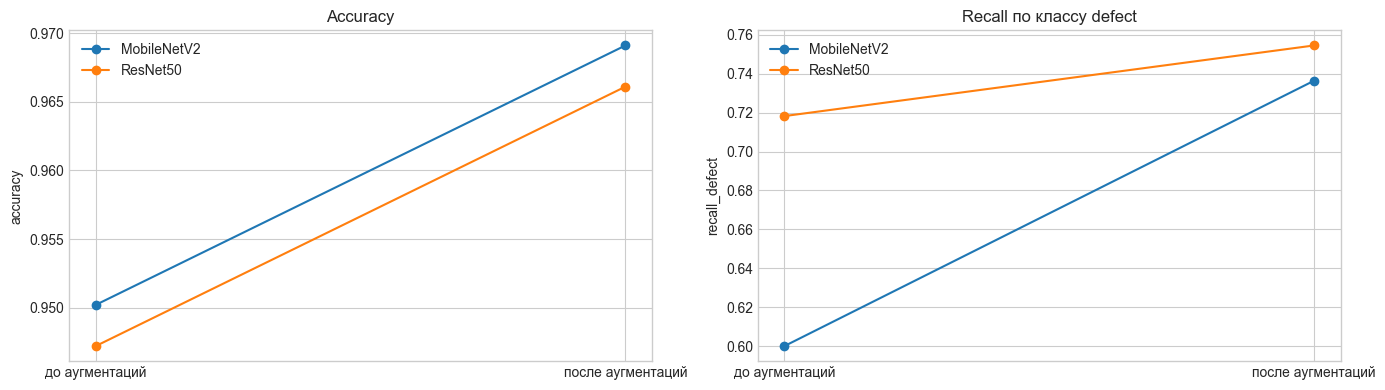

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for axis, metric_name, title in zip(
    axes,
    ["accuracy", "recall_defect"],
    ["Accuracy", "Recall по классу defect"],
):
    for model_name in experiment_metrics_table["модель"].unique():
        subset = experiment_metrics_table[experiment_metrics_table["модель"] == model_name]
        axis.plot(subset["сценарий"], subset[metric_name], marker="o", label=model_name)
    axis.set_title(title)
    axis.set_ylabel(metric_name)
    axis.legend()

plt.tight_layout()
plt.show()

In [11]:
history_table = pd.concat(
    [
        item["history"].assign(
            модель=item["model_name"],
            сценарий="после аугментаций" if item["use_balancing"] else "до аугментаций",
        )
        for item in experiment_results
    ],
    ignore_index=True,
)
history_table.head()

,epoch,train_loss,train_accuracy,val_loss,val_accuracy,val_recall_defect,val_precision_defect,val_f1_defect,defect_threshold,learning_rate,модель,сценарий
0,1,0.292716,0.908798,0.536955,0.957173,0.693878,0.871795,0.772727,0.5,0.0001,ResNet50,до аугментаций
1,2,0.110184,0.958691,0.220773,0.972163,0.816327,0.909091,0.860215,0.5,0.0001,ResNet50,до аугментаций
2,3,0.039831,0.984442,0.179590,0.967880,0.755102,0.925000,0.831461,0.5,0.0001,ResNet50,до аугментаций
3,4,0.012501,0.996781,0.181821,0.959315,0.836735,0.788462,0.811881,0.5,0.0001,ResNet50,до аугментаций
4,5,0.015088,0.996781,0.279974,0.961456,0.734694,0.878049,0.800000,0.5,0.0001,ResNet50,до аугментаций


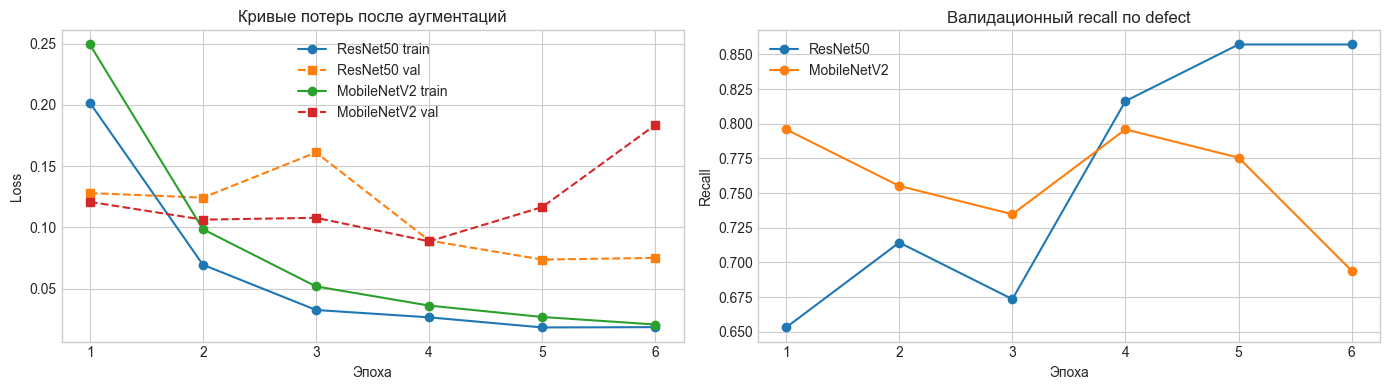

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for model_name in history_table["модель"].unique():
    subset = history_table[
        (history_table["модель"] == model_name)
        & (history_table["сценарий"] == "после аугментаций")
    ]
    axes[0].plot(subset["epoch"], subset["train_loss"], marker="o", label=f"{model_name} train")
    axes[0].plot(subset["epoch"], subset["val_loss"], marker="s", linestyle="--", label=f"{model_name} val")
    axes[1].plot(subset["epoch"], subset["val_recall_defect"], marker="o", label=model_name)

axes[0].set_title("Кривые потерь после аугментаций")
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].set_title("Валидационный recall по defect")
axes[1].set_xlabel("Эпоха")
axes[1].set_ylabel("Recall")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Финальные модели и итоговые метрики

In [13]:
if not Path(RESNET_MODEL_PATH).exists():
    _ = train_and_save_resnet()
if not Path(MOBILENET_MODEL_PATH).exists():
    _ = train_and_save_mobilenet()

_, _, test_loader, train_used_df, val_used_df, test_used_df = make_loaders(
    use_balancing=True,
    use_positive_augmentation=True,
)

resnet_model = initialize_resnet50().to(DEVICE)
resnet_model.load_state_dict(torch.load(RESNET_MODEL_PATH, map_location=DEVICE))

mobilenet_model = initialize_mobilenet_v2().to(DEVICE)
mobilenet_model.load_state_dict(torch.load(MOBILENET_MODEL_PATH, map_location=DEVICE))

criterion = nn.CrossEntropyLoss()
resnet_metrics = evaluate_model(resnet_model, test_loader, criterion, device=DEVICE)
mobilenet_metrics = evaluate_model(mobilenet_model, test_loader, criterion, device=DEVICE)

final_metrics_table = pd.DataFrame(
    [
        {"модель": "ResNet50", **resnet_metrics},
        {"модель": "MobileNetV2", **mobilenet_metrics},
    ]
)[
    ["модель", "accuracy", "precision_defect", "recall_defect", "f1_defect", "loss", "mean_defect_probability"]
].round(4)

final_metrics_table

C:\Users\kitub\AppData\Local\Temp\ipykernel_13508\2775622258.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  resnet_model.load_state_dict(torch.load(RESNET_MODEL_PATH, 

,модель,accuracy,precision_defect,recall_defect,f1_defect,loss,mean_defect_probability
0,ResNet50,0.9721,0.9362,0.8000,0.8627,0.1882,0.0940
1,MobileNetV2,0.9631,0.9740,0.6818,0.8021,0.1750,0.0822


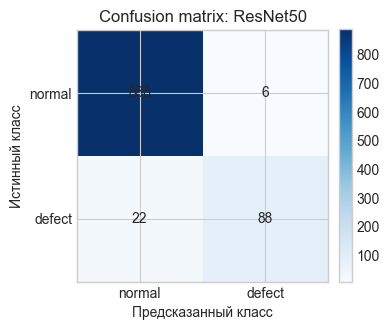

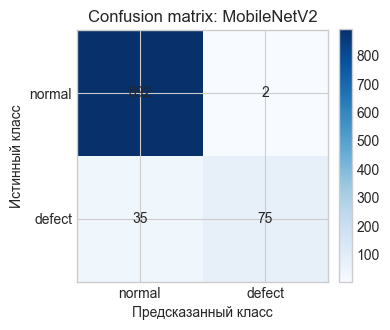

In [14]:
def plot_confusion_matrix(metrics: dict, title: str):
    matrix = np.array(metrics["confusion_matrix"])
    fig, ax = plt.subplots(figsize=(4, 4))
    image = ax.imshow(matrix, cmap="Blues")
    for row_index in range(matrix.shape[0]):
        for col_index in range(matrix.shape[1]):
            ax.text(col_index, row_index, str(matrix[row_index, col_index]), ha="center", va="center")
    ax.set_xlabel("Предсказанный класс")
    ax.set_ylabel("Истинный класс")
    ax.set_title(title)
    ax.set_xticks([0, 1], ["normal", "defect"])
    ax.set_yticks([0, 1], ["normal", "defect"])
    plt.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(resnet_metrics, "Confusion matrix: ResNet50")
plot_confusion_matrix(mobilenet_metrics, "Confusion matrix: MobileNetV2")

## 6. Monitoring и симуляция деградации входа

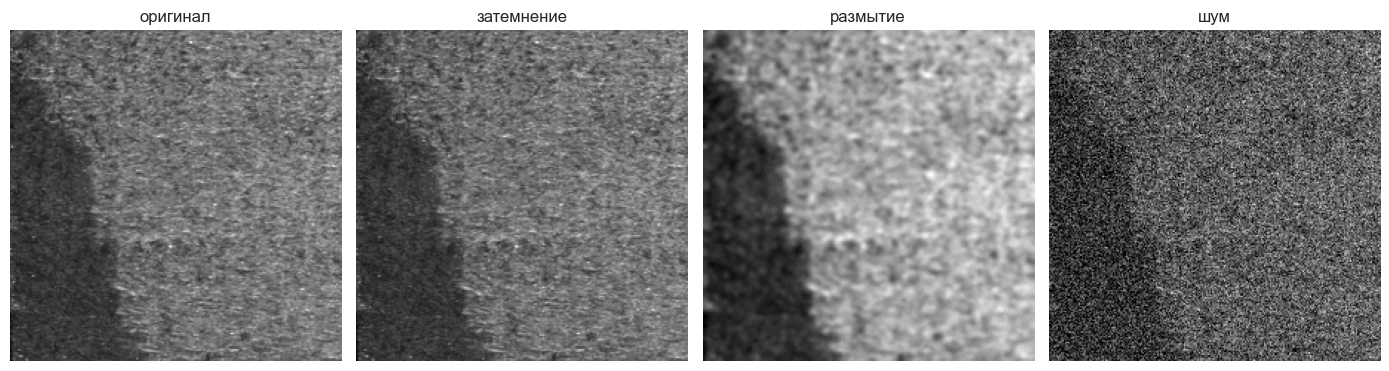

In [15]:
sample_row = test_df.iloc[0]
sample_path = sample_row["image_path"]
sample_gray = np.array(Image.open(sample_path).convert("L").resize((224, 224)))

degraded_images = {
    "оригинал": sample_gray,
    "затемнение": darken_image(sample_gray, factor=0.5),
    "размытие": blur_image(sample_gray, kernel_size=(7, 7)),
    "шум": add_gaussian_noise(sample_gray, std=18.0),
}

fig, axes = plt.subplots(1, len(degraded_images), figsize=(14, 4))
for axis, (title, image_array) in zip(axes, degraded_images.items()):
    axis.imshow(image_array, cmap="gray")
    axis.set_title(title)
    axis.axis("off")
plt.tight_layout()
plt.show()

In [16]:
monitoring_rows = []
for title, image_array in degraded_images.items():
    signals = collect_monitoring_signals(image_array, probabilities=np.array([0.55, 0.45]))
    monitoring_rows.append({"сценарий": title, **signals})

monitoring_table = pd.DataFrame(monitoring_rows).round(4)
monitoring_table

,сценарий,brightness,blur_variance,confidence,entropy
0,оригинал,0.1612,219.7581,0.55,0.6881
1,затемнение,0.0796,56.1767,0.55,0.6881
2,размытие,0.1612,3.5675,0.55,0.6881
3,шум,0.1598,6400.4684,0.55,0.6881


## 7. Fallback-инференс и время обработки одного изображения

In [17]:
fallback_result = predict_with_fallback(
    image_path=sample_path,
    resnet_model=resnet_model,
    fallback_model=mobilenet_model,
    device=DEVICE,
    force_main_failure=False,
)

forced_fallback_result = predict_with_fallback(
    image_path=sample_path,
    resnet_model=resnet_model,
    fallback_model=mobilenet_model,
    device=DEVICE,
    force_main_failure=True,
)

pd.DataFrame([fallback_result, forced_fallback_result])

,prediction,source,confidence,fallback_used,monitoring,main_error
0,0,main_resnet50,0.999735,False,"{'brightness': 0.15875618159770966, 'blur_vari...",None
1,0,fallback_mobilenetv2,0.926351,True,"{'brightness': 0.15875618159770966, 'blur_vari...",Main model failure was simulated.


In [18]:
def measure_single_image_latency(model, image_path: str, repeats: int = 30):
    model.eval()
    image_tensor = load_image_tensor(image_path).to(DEVICE)

    for _ in range(5):
        with torch.no_grad():
            _ = model(image_tensor)
    if DEVICE == 'cuda':
        torch.cuda.synchronize()

    timings = []
    for _ in range(repeats):
        start = time.perf_counter()
        with torch.no_grad():
            _ = model(image_tensor)
        if DEVICE == 'cuda':
            torch.cuda.synchronize()
        timings.append((time.perf_counter() - start) * 1000)

    return {
        'mean_ms': float(np.mean(timings)),
        'std_ms': float(np.std(timings)),
        'min_ms': float(np.min(timings)),
        'max_ms': float(np.max(timings)),
    }


latency_table = pd.DataFrame(
    [
        {'model': 'ResNet50', **measure_single_image_latency(resnet_model, sample_path)},
        {'model': 'MobileNetV2', **measure_single_image_latency(mobilenet_model, sample_path)},
    ]
).round(3)

latency_table

,модель,mean_ms,std_ms,min_ms,max_ms
0,ResNet50,8.273,2.486,5.344,13.264
1,MobileNetV2,5.907,1.613,4.535,12.647


## 8. Выводы

Основные наблюдения:
- исходный train-набор сильно несбалансирован в сторону класса `normal`;
- после oversampling и аугментаций доля класса `defect` приближается к `50/50`;
- после балансировки модели обычно лучше удерживают `recall` по дефектам;
- `ResNet50` удобно использовать как основную модель;
- `MobileNetV2` подходит как fallback-модель, потому что она легче и быстрее;
- monitoring-сигналы помогают дополнительно отслеживать деградацию входа;
- замер задержки на одном изображении позволяет отдельно оценить практическую стоимость инференса.